# 🧬 Human Embryo Time-Lapse Classification
## Multiclass Image Classification using Transfer Learning

**Models**: MobileNetV1, MobileNetV2, InceptionV3, VGG16, VGG19  
**Custom Loss**: L_total = L_WCE + λ · L_ord (weighted cross-entropy + ordinal phase distance)  
**Dataset**: [embryo-dataset](https://www.kaggle.com/datasets/abhishekbuddiga06/embryo-dataset)

In [1]:
!pip uninstall torch torchvision torchaudio -y

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128


In [2]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 106.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 2.7 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 9.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 10.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━

In [4]:
!pip install -q torchsummary

In [10]:
import glob

In [7]:
# ===============================
# 🔹 Core Imports & Setup
# ===============================
import os
import re
import math
import time
import gc
import random
import warnings
from pathlib import Path
from collections import Counter, defaultdict

# 🔹 Numerical + Data Handling
import numpy as np
import pandas as pd

# 🔹 PyTorch Stack
import torch
import torch.nn as nn
import torch.optim as optimizer
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# 🔹 Vision Utilities
import torchvision.transforms as transforms
import torchvision.models as vision_models

# 🔹 Image Handling
from PIL import Image, ImageFile

# 🔹 Visualization + Metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 🔹 Model Summary
from torchsummary import summary

# ===============================
# 🔹 Runtime Configurations
# ===============================

# Handle corrupted images gracefully
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Suppress unnecessary warnings
warnings.simplefilter("ignore")

# ===============================
# 🔹 Device Configuration
# ===============================
def get_compute_device():
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
        print(f"🚀 Running on GPU: {gpu_name}")
        return torch.device("cuda")
    else:
        print("⚙️ Running on CPU")
        return torch.device("cpu")

device = get_compute_device()

🚀 Running on GPU: Tesla T4


##  Configuration

In [8]:
# -------------------- DATA PATHS --------------------
DATA_ROOT = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset'
IMAGE_DIR = os.path.join(DATA_ROOT, 'embryo_dataset/embryo_dataset')
ANNOT_DIR = os.path.join(DATA_ROOT, 'embryo_dataset_annotations/embryo_dataset_annotations')

assert os.path.isdir(IMAGE_DIR), f"Missing image folder -> {IMAGE_DIR}"
assert os.path.isdir(ANNOT_DIR), f"Missing annotation folder -> {ANNOT_DIR}"

print("📂 Dataset Paths:")
print(f" - Images: {IMAGE_DIR}")
print(f" - Labels: {ANNOT_DIR}")


# -------------------- DEVELOPMENT STAGES --------------------
# Ordered timeline (used for ordinal-aware loss)
PHASE_ORDER = [
    'tPB2', 'tPNa', 'tPNf',
    't2', 't3', 't4', 't5', 't6', 't7', 't8',
    't9+', 'tM', 'tSB', 'tB', 'tEB', 'tHB'
]


# -------------------- FRAME SAMPLING --------------------
FRAME_STRIDE = 3
MAX_FRAMES   = 2000


# -------------------- TRAINING CONFIG --------------------
TRAIN_CFG = {
    "batch_size": 128,
    "num_workers": 4,
    "learning_rate": 1e-4,
    "weight_decay": 1e-5,
    "ordinal_lambda": 2.0,
    "early_stop_patience": 3,
    "seed": 42
}


# -------------------- MODEL SETTINGS --------------------
EPOCH_MAP = {
    "mobilenet_v1": 5,
    "mobilenet_v2": 5,
    "inception_v3": 5,
    "vgg16": 5,
    "vgg19": 5
}

SELECTED_MODELS = [
    "mobilenet_v1",
    "mobilenet_v2",
    "inception_v3",
    "vgg16",
    "vgg19"
]


# -------------------- REPRODUCIBILITY --------------------
seed_val = TRAIN_CFG["seed"]
random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)

print("⚙️ Configuration initialized")

📂 Dataset Paths:
 - Images: /kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset/embryo_dataset
 - Labels: /kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset_annotations/embryo_dataset_annotations
⚙️ Configuration initialized


In [11]:
# -------------------- IMAGE DIRECTORY OVERVIEW --------------------
print("📸 IMAGE DIRECTORY SNAPSHOT")

video_folders = sorted(os.listdir(IMAGE_DIR))
print(f"Total video folders found: {len(video_folders)}")

if video_folders:
    sample_folder = video_folders[0]
    sample_path = os.path.join(IMAGE_DIR, sample_folder)

    print(f"\nSample folder → {sample_folder}/")

    preview_files = sorted(os.listdir(sample_path))[:10]
    for file_name in preview_files:
        print(f"   - {file_name}")


# -------------------- ANNOTATION DIRECTORY OVERVIEW --------------------
print("\n🧾 ANNOTATION FILES SNAPSHOT")

annotation_files = sorted(glob.glob(os.path.join(ANNOT_DIR, "*.csv")))
print(f"Total annotation files: {len(annotation_files)}")

if annotation_files:
    sample_csv = annotation_files[0]
    print(f"\nSample file → {Path(sample_csv).name}")

    sample_df = pd.read_csv(
        sample_csv,
        header=None,
        names=["phase", "start_frame", "end_frame"]
    )

    print(sample_df.head(10))

📸 IMAGE DIRECTORY SNAPSHOT
Total video folders found: 704

Sample folder → AA83-7/
   - D2013.01.28_S0717_I132_WELL7_RUN1.jpeg
   - D2013.01.28_S0717_I132_WELL7_RUN10.jpeg
   - D2013.01.28_S0717_I132_WELL7_RUN100.jpeg
   - D2013.01.28_S0717_I132_WELL7_RUN101.jpeg
   - D2013.01.28_S0717_I132_WELL7_RUN102.jpeg
   - D2013.01.28_S0717_I132_WELL7_RUN103.jpeg
   - D2013.01.28_S0717_I132_WELL7_RUN104.jpeg
   - D2013.01.28_S0717_I132_WELL7_RUN105.jpeg
   - D2013.01.28_S0717_I132_WELL7_RUN106.jpeg
   - D2013.01.28_S0717_I132_WELL7_RUN107.jpeg

🧾 ANNOTATION FILES SNAPSHOT
Total annotation files: 704

Sample file → AA83-7_phases.csv
  phase  start_frame  end_frame
0  tPB2            5         24
1  tPNa           25         88
2  tPNf           89         97
3    t2           98        171
4    t3          172        177
5    t4          178        191
6    t5          192        241
7    t6          242        256
8    t7          257        276
9    t8          277        286


## 🔍 Explore Dataset Structure

In [12]:
# -------------------- FRAME INDEX EXTRACTION --------------------
def parse_frame_index(fname):
    name = Path(fname).stem

    run_match = re.search(r'RUN(\d+)', name, re.IGNORECASE)
    if run_match:
        return int(run_match.group(1))

    nums = re.findall(r'(\d+)', name)
    return int(nums[-1]) if nums else None


# -------------------- LOAD ANNOTATIONS --------------------
def read_annotation_files(annot_path):
    ann_map = {}

    csv_list = sorted(Path(annot_path).glob("*.csv"))

    for file in csv_list:
        base_name = file.stem

        for suf in ['_phases', '_phase', '_annotations', '_annot', '_labels']:
            if base_name.endswith(suf):
                base_name = base_name[:-len(suf)]
                break

        try:
            df = pd.read_csv(
                file,
                header=None,
                names=["phase", "start_frame", "end_frame"]
            )

            df["phase"] = df["phase"].astype(str).str.strip()
            df["start_frame"] = pd.to_numeric(df["start_frame"], errors="coerce")
            df["end_frame"] = pd.to_numeric(df["end_frame"], errors="coerce")

            df = df.dropna(subset=["phase", "start_frame", "end_frame"])
            df[["start_frame", "end_frame"]] = df[["start_frame", "end_frame"]].astype(int)

            if not df.empty:
                ann_map[base_name] = df

        except Exception as err:
            print(f"⚠️ Skipped {file} -> {err}")

    print(f"Loaded annotations: {len(ann_map)} videos")

    sample_keys = sorted(ann_map.keys())[:5]
    print(f"Preview keys: {sample_keys}")

    if sample_keys:
        sample_df = ann_map[sample_keys[0]]
        print(f"Phases sample: {list(sample_df['phase'])}")
        print(f"Frame span: {sample_df['start_frame'].min()} → {sample_df['end_frame'].max()}")

    return ann_map


# -------------------- LABEL RESOLUTION --------------------
def resolve_label(frame_id, ann_df):
    for _, row in ann_df.iterrows():
        if row["start_frame"] <= frame_id <= row["end_frame"]:
            return str(row["phase"]).strip()
    return None


# -------------------- MATCH VIDEO TO ANNOTATION --------------------
def find_annotation(video_name, ann_map):
    if video_name in ann_map:
        return ann_map[video_name]

    v_low = video_name.lower()

    for key in ann_map:
        if key.lower() == v_low:
            return ann_map[key]

    for key in ann_map:
        if key.lower() in v_low or v_low in key.lower():
            return ann_map[key]

    return None


# -------------------- DATASET BUILDER --------------------
def create_dataset(img_root, ann_map, step=3, max_frames=2000):
    data = []
    missing_ann, missing_lbl = 0, 0

    video_list = sorted([
        d for d in os.listdir(img_root)
        if os.path.isdir(os.path.join(img_root, d))
    ])

    print(f"Discovered {len(video_list)} video folders")

    for vid in video_list:
        vid_path = os.path.join(img_root, vid)
        ann_df = find_annotation(vid, ann_map)

        if ann_df is None:
            missing_ann += 1
            continue

        img_list = sorted(
            list(Path(vid_path).glob("*.jpg")) +
            list(Path(vid_path).glob("*.jpeg")) +
            list(Path(vid_path).glob("*.png"))
        )

        if not img_list:
            img_list = sorted(
                list(Path(vid_path).glob("**/*.jpg")) +
                list(Path(vid_path).glob("**/*.jpeg")) +
                list(Path(vid_path).glob("**/*.png"))
            )

        frames = []
        for img_path in img_list:
            frame_id = parse_frame_index(img_path.name)
            if frame_id is not None:
                frames.append((str(img_path), frame_id))

        frames.sort(key=lambda x: x[1])
        frames = frames[::step]

        if len(frames) > max_frames:
            idx = np.linspace(0, len(frames) - 1, max_frames, dtype=int)
            frames = [frames[i] for i in idx]

        for img_path, frame_id in frames:
            lbl = resolve_label(frame_id, ann_df)
            if lbl:
                data.append((img_path, lbl, vid, frame_id))
            else:
                missing_lbl += 1

    print(f"\nFinal dataset size: {len(data)}")
    print(f"Missing annotations: {missing_ann}")
    print(f"Missing labels: {missing_lbl}")

    return data


# -------------------- EXECUTION --------------------
annotations = read_annotation_files(ANNOT_DIR)

dataset_raw = create_dataset(
    IMAGE_DIR,
    annotations,
    step=FRAME_STRIDE,     # ✅ fixed
    max_frames=MAX_FRAMES  # ✅ fixed
)

Loaded annotations: 704 videos
Preview keys: ['AA83-7', 'AAL839-6', 'AB028-6', 'AB91-1', 'AC264-1']
Phases sample: ['tPB2', 'tPNa', 'tPNf', 't2', 't3', 't4', 't5', 't6', 't7', 't8']
Frame span: 5 → 286
Discovered 704 video folders

Final dataset size: 99142
Missing annotations: 0
Missing labels: 15211


##  1. Data Preparation
Read CSVs → extract frame numbers from RUN index → map to phase labels → sample

Detected 16 classes:
['t2', 't3', 't4', 't5', 't6', 't7', 't8', 't9+', 'tB', 'tEB', 'tHB', 'tM', 'tPB2', 'tPNa', 'tPNf', 'tSB'] 

Class frequency overview:
            t2 :   9732
            t3 :   1706
            t4 :   9730
            t5 :   2674
            t6 :   2782
            t7 :   3529
            t8 :  10847
           t9+ :  17048
            tB :   3464
           tEB :   6518
           tHB :     33
            tM :   5707
          tPB2 :   2956
          tPNa :  14409
          tPNf :   2268
           tSB :   5739


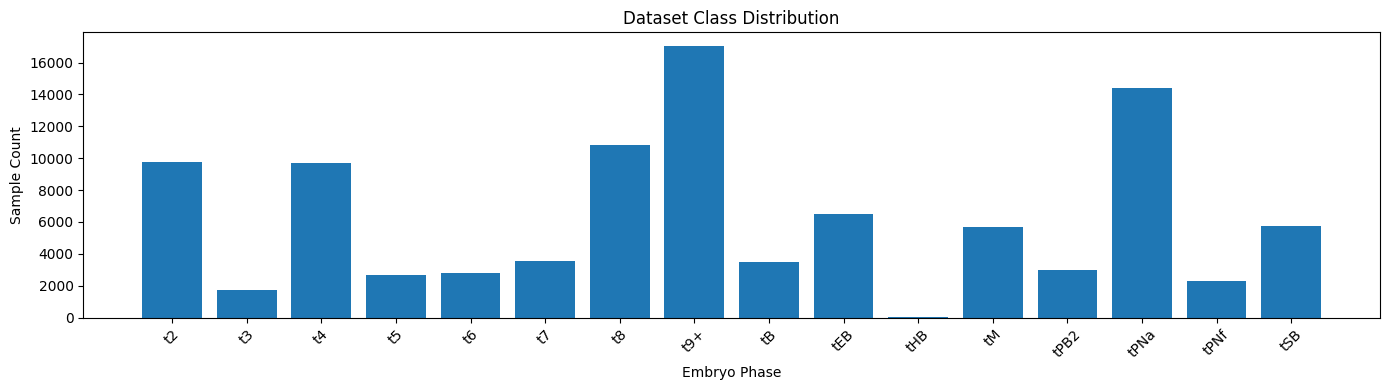


Ordinal ranking per class:
      t2 → rank 3
      t3 → rank 4
      t4 → rank 5
      t5 → rank 6
      t6 → rank 7
      t7 → rank 8
      t8 → rank 9
     t9+ → rank 10
      tB → rank 13
     tEB → rank 14
     tHB → rank 15
      tM → rank 11
    tPB2 → rank 0
    tPNa → rank 1
    tPNf → rank 2
     tSB → rank 12

Computed class weights:
[ 0.345  0.421  0.345  0.37   0.368  0.355  0.345  0.345  0.356  0.345
 10.619  0.346  0.364  0.345  0.385  0.346]


In [20]:
# -------------------- LABEL SETUP --------------------
labels_list = sorted({item[1] for item in dataset_raw})

label_to_id = {name: idx for idx, name in enumerate(labels_list)}
id_to_label = {idx: name for name, idx in label_to_id.items()}

NUM_CLASSES = len(labels_list)

print(f"Detected {NUM_CLASSES} classes:")
print(labels_list, "\n")


# -------------------- CLASS DISTRIBUTION --------------------
label_freq = Counter(item[1] for item in dataset_raw)

print("Class frequency overview:")
for name in labels_list:
    print(f"  {name:>12s} : {label_freq[name]:>6d}")


# -------------------- VISUALIZATION --------------------
fig, axis = plt.subplots(figsize=(14, 4))

freq_array = np.array([label_freq[x] for x in labels_list], dtype=float)
axis.bar(labels_list, freq_array)

axis.set_xlabel("Embryo Phase")
axis.set_ylabel("Sample Count")
axis.set_title("Dataset Class Distribution")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# -------------------- ORDINAL MAPPING --------------------
ordinal_map = torch.zeros(NUM_CLASSES)

for order_idx, phase_name in enumerate(PHASE_ORDER):
    if phase_name in label_to_id:
        ordinal_map[label_to_id[phase_name]] = float(order_idx)

ordinal_map = ordinal_map.to(device)

print("\nOrdinal ranking per class:")
for idx in range(NUM_CLASSES):
    print(f"  {id_to_label[idx]:>6s} → rank {int(ordinal_map[idx].item())}")


# -------------------- CLASS WEIGHTING (EFFECTIVE SAMPLES) --------------------
beta = 0.999

eff_num = 1.0 - np.power(beta, freq_array)
weights = (1.0 - beta) / eff_num

weights = weights / weights.sum() * NUM_CLASSES

class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print("\nComputed class weights:")
print(class_weights.cpu().numpy().round(3))

##  2. Video-Wise Train / Val / Test Split

In [21]:
# -------------------- VIDEO-LEVEL SPLIT --------------------
def split_by_video(data, val_frac=0.15, test_frac=0.15):
    grouped = defaultdict(list)

    # Group samples by video ID
    for sample in data:
        vid_name = sample[2]
        grouped[vid_name].append(sample)

    video_ids = list(grouped.keys())
    video_ids.sort()
    random.shuffle(video_ids)

    total_vids = len(video_ids)

    test_count = max(1, int(total_vids * test_frac))
    val_count  = max(1, int(total_vids * val_frac))

    test_set_vids = video_ids[:test_count]
    val_set_vids  = video_ids[test_count:test_count + val_count]
    train_set_vids = video_ids[test_count + val_count:]

    # Flatten grouped samples
    train_data = [item for vid in train_set_vids for item in grouped[vid]]
    val_data   = [item for vid in val_set_vids   for item in grouped[vid]]
    test_data  = [item for vid in test_set_vids  for item in grouped[vid]]

    print(
        f"Split Summary → "
        f"Train: {len(train_data)} ({len(train_set_vids)} vids), "
        f"Val: {len(val_data)} ({len(val_set_vids)} vids), "
        f"Test: {len(test_data)} ({len(test_set_vids)} vids)"
    )

    return train_data, val_data, test_data


# -------------------- EXECUTION --------------------
train_raw, val_raw, test_raw = split_by_video(dataset_raw)

Split Summary → Train: 69851 (494 vids), Val: 14316 (105 vids), Test: 14975 (105 vids)


##  3. Dataset & DataLoaders

In [22]:
# -------------------- DATASET CLASS --------------------
class EmbryoFrameDataset(Dataset):
    def __init__(self, samples, label_map, transform=None):
        self.samples = samples
        self.label_map = label_map
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        try:
            img_path, label, vid, frame_id = self.samples[index]

            image = Image.open(img_path).convert("RGB")

            if self.transform is not None:
                image = self.transform(image)

            return image, self.label_map[label]

        except (OSError, IOError, SyntaxError):
            # Skip broken images safely
            new_index = (index + 1) % len(self.samples)
            return self.__getitem__(new_index)


# -------------------- IMAGE TRANSFORMS --------------------
def build_transforms(size=224, train_mode=True):
    base_ops = [
        T.Resize((size, size)),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406],
                    [0.229, 0.224, 0.225])
    ]

    if train_mode:
        aug_ops = [
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(10),
            T.ColorJitter(brightness=0.1, contrast=0.1)
        ]
        return T.Compose([*([T.Resize((size, size))] + aug_ops + base_ops[1:])])

    return T.Compose(base_ops)


# -------------------- DATALOADER CREATION --------------------
def create_data_loaders(train_data, val_data, test_data, label_map, img_size=224, batch_size=32):
    
    train_ds = EmbryoFrameDataset(train_data, label_map, build_transforms(img_size, True))
    val_ds   = EmbryoFrameDataset(val_data,   label_map, build_transforms(img_size, False))
    test_ds  = EmbryoFrameDataset(test_data,  label_map, build_transforms(img_size, False))

    # Handle class imbalance via sampling
    freq = Counter(item[1] for item in train_data)
    weights = [1.0 / freq[item[1]] for item in train_data]

    sampler = WeightedRandomSampler(weights, num_samples=len(train_data), replacement=True)

    loader_args = {
        "num_workers": NUM_WORKERS,
        "pin_memory": True
    }

    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, **loader_args)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, **loader_args)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, **loader_args)

    print(f"Loaders configured → img_size={img_size}, batch_size={batch_size}")
    print(f"Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

    return train_loader, val_loader, test_loader


print("Dataset pipeline initialized ✅")

Dataset pipeline initialized ✅


##  4. Unified Model Framework

In [23]:
# -------------------- MODEL FACTORY --------------------
def create_model(arch_name, n_classes, freeze_portion=0.8):
    img_dim = 224

    if arch_name in ["mobilenet_v1", "mobilenet_v2"]:
        net = models.mobilenet_v2(weights="IMAGENET1K_V1")
        in_features = net.classifier[1].in_features

        net.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, n_classes)
        )

    elif arch_name == "inception_v3":
        net = models.inception_v3(weights="IMAGENET1K_V1", aux_logits=True)

        net.fc = nn.Linear(net.fc.in_features, n_classes)
        net.AuxLogits.fc = nn.Linear(net.AuxLogits.fc.in_features, n_classes)

        img_dim = 299

    elif arch_name == "vgg16":
        net = models.vgg16(weights="IMAGENET1K_V1")
        net.classifier[6] = nn.Linear(net.classifier[6].in_features, n_classes)

    elif arch_name == "vgg19":
        net = models.vgg19(weights="IMAGENET1K_V1")
        net.classifier[6] = nn.Linear(net.classifier[6].in_features, n_classes)

    else:
        raise ValueError(f"Unsupported architecture: {arch_name}")

    # -------------------- PARAMETER FREEZING --------------------
    all_params = list(net.parameters())
    total_count = sum(p.numel() for p in all_params)

    freeze_limit = int(total_count * freeze_portion)
    running_sum = 0

    for param in all_params:
        if running_sum < freeze_limit:
            param.requires_grad = False
            running_sum += param.numel()
        else:
            param.requires_grad = True

    # -------------------- STATS --------------------
    trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in net.parameters())

    print(f"{arch_name} → Trainable: {trainable_params:,} / Total: {total_params:,}")

    return net.to(device), img_dim


print("Model builder initialized ✅")

Model builder initialized ✅


##  5. Custom Loss Function

### Total Loss = L_WCE + λ · L_ord

**L_WCE**—Weighted Cross-Entropy Loss (handles class imbalance):  
$$\mathcal{L}_{WCE} = -\sum_{c=1}^{C} w_c \cdot y_c \cdot \log(\hat{y}_c)$$

**L_ord**—Ordinal Phase Distance Loss:  
$$\mathcal{L}_{ord} = \frac{1}{B} \sum_{b=1}^{B} \left(\frac{\hat{r}_b - r_{y_b}}{C - 1}\right)^2$$

where:
- $\hat{r}_b = \sum_{c=1}^{C} p_{bc} \cdot o_c$ — expected developmental rank from softmax probabilities
- $r_{y_b} = o_{y_b}$ — true developmental rank of ground-truth class
- $o_c$ — ordinal position of class $c$ in the biological timeline (0 = tPB2 … 15 = tHB)

### Why this works
- **Differentiable**: gradients flow through softmax → expected rank
- **Ordinal-aware**: predicting phase 1 when truth is phase 3 gives loss $(2/15)^2 = 0.018$, but predicting phase 1 when truth is phase 12 gives $(11/15)^2 = 0.538$—~30× more penalty**
- **Convergence**: smooth quadratic penalty gives strong, consistent gradients
- **λ controls trade-off**: classification accuracy vs. ordinal coherence

In [24]:
# -------------------- ORDINAL-AWARE LOSS --------------------
class PhaseDistanceLoss(nn.Module):
    """
    Measures prediction error based on developmental distance.
    """

    def __init__(self, ord_tensor):
        super().__init__()
        self.register_buffer("rank_map", ord_tensor.float())
        self.num_classes = len(ord_tensor)

    def forward(self, logits, targets):
        prob_dist = F.softmax(logits, dim=1)  # (B, C)

        pred_pos = (prob_dist * self.rank_map.unsqueeze(0)).sum(dim=1)
        true_pos = self.rank_map[targets]

        norm_diff = (pred_pos - true_pos) / (self.num_classes - 1)
        return (norm_diff ** 2).mean()


# -------------------- COMBINED LOSS --------------------
class HybridLoss(nn.Module):
    """
    Total Loss = Weighted CrossEntropy + alpha * Ordinal Distance
    """

    def __init__(self, weights, ord_tensor, alpha=2.0):
        super().__init__()
        self.ce_loss = nn.CrossEntropyLoss(weight=weights)
        self.dist_loss = PhaseDistanceLoss(ord_tensor)
        self.alpha = alpha

    def forward(self, logits, targets):
        ce_val = self.ce_loss(logits, targets)
        ord_val = self.dist_loss(logits, targets)

        total_loss = ce_val + self.alpha * ord_val
        return total_loss, ce_val.item(), ord_val.item()


# -------------------- INITIALIZATION --------------------
loss_fn = HybridLoss(class_weights, ordinal_map, alpha=2.0)

print(f"Loss module ready → CE + {loss_fn.alpha} × ordinal penalty")

Loss module ready → CE + 2.0 × ordinal penalty


##  6. Training with Early Stopping

In [27]:
# -------------------- TRAIN (ONE EPOCH) --------------------
def run_train_epoch(net, data_loader, loss_fn, opt, arch_name):
    net.train()

    loss_sum, ce_sum, ord_sum = 0, 0, 0
    correct_preds, total_samples = 0, 0

    for batch_imgs, batch_labels in data_loader:
        batch_imgs = batch_imgs.to(device)
        batch_labels = batch_labels.to(device)

        opt.zero_grad()

        outputs = net(batch_imgs)

        # Handle Inception-style outputs
        if isinstance(outputs, tuple):
            main_out, aux_out = outputs

            main_loss, ce_val, ord_val = loss_fn(main_out, batch_labels)
            aux_loss, _, _ = loss_fn(aux_out, batch_labels)

            final_loss = main_loss + 0.4 * aux_loss
            logits = main_out
        else:
            logits = outputs
            final_loss, ce_val, ord_val = loss_fn(logits, batch_labels)

        final_loss.backward()
        opt.step()

        batch_size = batch_labels.size(0)

        loss_sum += final_loss.item() * batch_size
        ce_sum   += ce_val * batch_size
        ord_sum  += ord_val * batch_size

        _, predictions = logits.max(1)
        correct_preds += predictions.eq(batch_labels).sum().item()
        total_samples += batch_size

    return (
        loss_sum / total_samples,
        ce_sum / total_samples,
        ord_sum / total_samples,
        correct_preds / total_samples
    )


# -------------------- VALIDATION --------------------
@torch.no_grad()
def run_evaluation(net, data_loader, loss_fn, arch_name):
    net.eval()

    loss_sum, correct_preds, total_samples = 0, 0, 0
    pred_list, label_list = [], []

    for batch_imgs, batch_labels in data_loader:
        batch_imgs = batch_imgs.to(device)
        batch_labels = batch_labels.to(device)

        outputs = net(batch_imgs)

        logits = outputs[0] if isinstance(outputs, tuple) else outputs

        loss_val, _, _ = loss_fn(logits, batch_labels)

        batch_size = batch_labels.size(0)
        loss_sum += loss_val.item() * batch_size

        _, predictions = logits.max(1)
        correct_preds += predictions.eq(batch_labels).sum().item()
        total_samples += batch_size

        pred_list.extend(predictions.cpu().numpy())
        label_list.extend(batch_labels.cpu().numpy())

    return (
        loss_sum / total_samples,
        correct_preds / total_samples,
        np.array(pred_list),
        np.array(label_list)
    )


# -------------------- TRAINING LOOP --------------------
def fit_model(net, train_loader, val_loader, loss_fn, opt,
              epochs, early_stop, arch_name):

    best_loss = float("inf")
    patience_counter = 0
    best_weights = None

    logs = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": [],
        "ce": [], "ord": []
    }

    for ep in range(epochs):
        start_time = time.time()

        tr_loss, tr_ce, tr_ord, tr_acc = run_train_epoch(
            net, train_loader, loss_fn, opt, arch_name
        )

        val_loss, val_acc, _, _ = run_evaluation(
            net, val_loader, loss_fn, arch_name
        )

        duration = time.time() - start_time

        logs["train_loss"].append(tr_loss)
        logs["train_acc"].append(tr_acc)
        logs["val_loss"].append(val_loss)
        logs["val_acc"].append(val_acc)
        logs["ce"].append(tr_ce)
        logs["ord"].append(tr_ord)

        print(
            f"Epoch {ep+1}/{epochs} | "
            f"Train Loss: {tr_loss:.4f} (CE:{tr_ce:.4f}, Ord:{tr_ord:.4f}) | "
            f"Acc: {tr_acc:.4f} || "
            f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f} | "
            f"{duration:.0f}s"
        )

        # -------------------- EARLY STOPPING --------------------
        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
            best_weights = {k: v.cpu().clone() for k, v in net.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= early_stop:
                print(f"Stopping early at epoch {ep+1}")
                break

    # Restore best model
    if best_weights is not None:
        net.load_state_dict({k: v.to(device) for k, v in best_weights.items()})

    return net, logs


print("Training pipeline ready 🚀")

Training pipeline ready 🚀


##  7. Evaluation

In [28]:
# -------------------- MODEL EVALUATION --------------------
def evaluate_model_performance(net, test_loader, loss_fn, id_to_label, arch_name):
    
    _, test_accuracy, predictions, targets = run_evaluation(
        net, test_loader, loss_fn, arch_name
    )

    print("\n" + "=" * 60)
    print(f"{arch_name.upper()} → Test Accuracy: {test_accuracy * 100:.2f}%")
    print("=" * 60)

    # ✅ FIX: explicitly define labels
    labels = list(range(len(id_to_label)))
    class_names = [id_to_label[i] for i in labels]

    print(classification_report(
        targets,
        predictions,
        labels=labels,              # ✅ KEY FIX
        target_names=class_names,
        zero_division=0
    ))

    # -------------------- CONFUSION MATRIX --------------------
    cmatrix = confusion_matrix(targets, predictions, labels=labels)

    fig, axis = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        cmatrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axis
    )

    axis.set_xlabel("Predicted Label")
    axis.set_ylabel("True Label")
    axis.set_title(f"Confusion Matrix — {arch_name}")

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return {
        "model": arch_name,
        "accuracy": test_accuracy
    }

# -------------------- TRAINING HISTORY VISUALIZATION --------------------
def visualize_training(history_log, arch_name):
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    epochs = range(1, len(history_log["train_loss"]) + 1)

    # ---- Total Loss ----
    axes[0].plot(epochs, history_log["train_loss"], marker="o", label="Train")
    axes[0].plot(epochs, history_log["val_loss"], marker="o", label="Validation")
    axes[0].set_title(f"{arch_name} — Loss")
    axes[0].legend()

    # ---- Accuracy ----
    axes[1].plot(epochs, history_log["train_acc"], marker="o", label="Train")
    axes[1].plot(epochs, history_log["val_acc"], marker="o", label="Validation")
    axes[1].set_title(f"{arch_name} — Accuracy")
    axes[1].legend()

    # ---- Loss Components ----
    axes[2].plot(epochs, history_log["ce"], marker="o", label="CrossEntropy")
    axes[2].plot(epochs, history_log["ord"], marker="o", label="Ordinal")
    axes[2].set_title(f"{arch_name} — Loss Breakdown")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


print("Evaluation utilities ready 📊")

Evaluation utilities ready 📊


##  8. Trainable Parameters & Model Summary

**Parameter formula:**
$$\text{params} = (\text{in\_features} \times \text{out\_features}) + \text{bias}$$

**Linear(1280, 16):** Weight = 1280 × 16 = 20,480 | Bias = 16 | **Total = 20,496**

**Conv2d(64, 128, 3×3):** Weight = 64 × 128 × 3 × 3 = 73,728 | Bias = 128 | **Total = 73,856**

In [29]:
# -------------------- REQUIRED IMPORT --------------------
import torchvision.models as models

NUM_CLASSES = len(labels_list)
# -------------------- MODEL SUMMARY UTILITY --------------------
def show_model_overview(arch_name, n_classes):
    
    net, img_dim = create_model(arch_name, n_classes, freeze_portion=0.0)

    print("\n" + "=" * 60)
    print(f"{arch_name.upper()} → MODEL SUMMARY")
    print("=" * 60)

    try:
        summary(net, (3, img_dim, img_dim), device=str(device))
    except Exception:
        total_params = sum(p.numel() for p in net.parameters())
        trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)

        print(f"Total Parameters: {total_params:,}")
        print(f"Trainable Parameters: {trainable_params:,}")

    # Clear memory
    del net
    torch.cuda.empty_cache()


# -------------------- RUN FOR ALL MODELS --------------------
model_list = [
    "mobilenet_v1",
    "mobilenet_v2",
    "inception_v3",
    "vgg16",
    "vgg19"
]

for arch in model_list:
    show_model_overview(arch, NUM_CLASSES)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 117MB/s] 


mobilenet_v1 → Trainable: 2,244,368 / Total: 2,244,368

MOBILENET_V1 → MODEL SUMMARY
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
             ReLU6-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
             ReLU6-6         [-1, 32, 112, 112]               0
            Conv2d-7         [-1, 16, 112, 112]             512
       BatchNorm2d-8         [-1, 16, 112, 112]              32
  InvertedResidual-9         [-1, 16, 112, 112]               0
           Conv2d-10         [-1, 96, 112, 112]           1,536
      BatchNorm2d-11         [-1, 96, 112, 112]             192
            ReLU6-12         [-1, 96, 112, 112]               0
           Conv2d-

100%|██████████| 104M/104M [00:00<00:00, 197MB/s]  


inception_v3 → Trainable: 24,388,352 / Total: 24,388,352

INCEPTION_V3 → MODEL SUMMARY
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 149, 149]             864
       BatchNorm2d-2         [-1, 32, 149, 149]              64
       BasicConv2d-3         [-1, 32, 149, 149]               0
            Conv2d-4         [-1, 32, 147, 147]           9,216
       BatchNorm2d-5         [-1, 32, 147, 147]              64
       BasicConv2d-6         [-1, 32, 147, 147]               0
            Conv2d-7         [-1, 64, 147, 147]          18,432
       BatchNorm2d-8         [-1, 64, 147, 147]             128
       BasicConv2d-9         [-1, 64, 147, 147]               0
        MaxPool2d-10           [-1, 64, 73, 73]               0
           Conv2d-11           [-1, 80, 73, 73]           5,120
      BatchNorm2d-12           [-1, 80, 73, 73]             160
      BasicConv2

100%|██████████| 528M/528M [00:02<00:00, 210MB/s]  


vgg16 → Trainable: 134,326,096 / Total: 134,326,096

VGG16 → MODEL SUMMARY
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13        

100%|██████████| 548M/548M [00:02<00:00, 227MB/s]  


vgg19 → Trainable: 139,635,792 / Total: 139,635,792

VGG19 → MODEL SUMMARY
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13        

## 🎯 9. Train & Evaluate Models

In [43]:
import torch.optim as optim

In [60]:
all_result = []


######################################################################
#  MOBILENET_V1
######################################################################
mobilenet_v1 → Trainable: 433,296 / Total: 2,244,368
Loaders ready → img_size=224, batch_size=128
Train: 546 | Val: 112 | Test: 117
Epoch 1/5 | Train Loss: 0.8313 (CE:0.7786, Ord:0.0264) | Acc: 0.3155 || Val Loss: 1.8053, Acc: 0.3977 | 240s
Epoch 2/5 | Train Loss: 0.6270 (CE:0.5983, Ord:0.0143) | Acc: 0.4354 || Val Loss: 1.7132, Acc: 0.4026 | 235s
Epoch 3/5 | Train Loss: 0.5944 (CE:0.5691, Ord:0.0126) | Acc: 0.4641 || Val Loss: 1.7076, Acc: 0.4000 | 240s
Epoch 4/5 | Train Loss: 0.5689 (CE:0.5454, Ord:0.0118) | Acc: 0.4871 || Val Loss: 1.6907, Acc: 0.4112 | 233s
Epoch 5/5 | Train Loss: 0.5471 (CE:0.5249, Ord:0.0111) | Acc: 0.4978 || Val Loss: 1.6307, Acc: 0.4325 | 233s


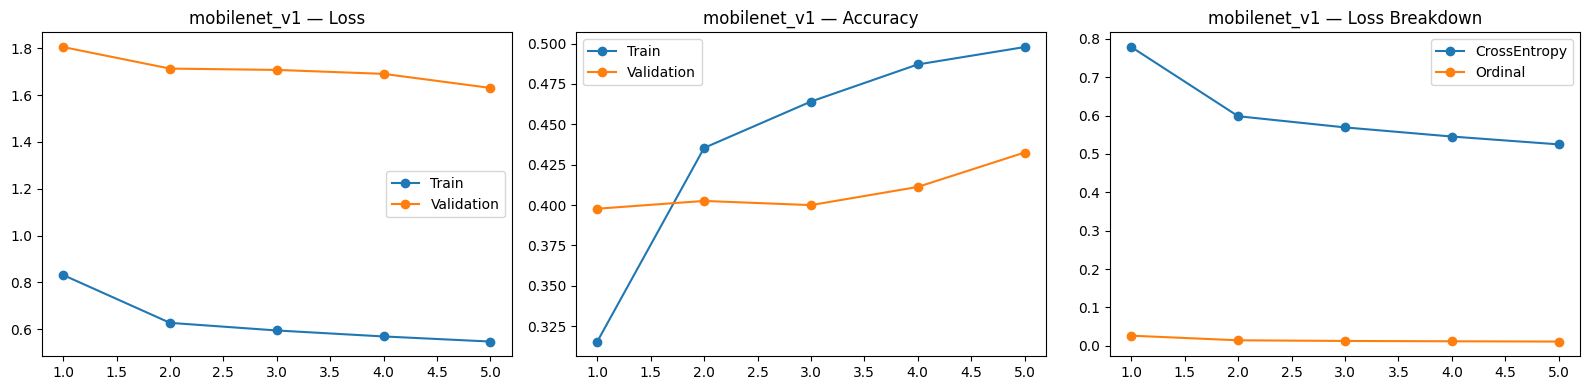


MOBILENET_V1 → Test Accuracy: 40.94%
              precision    recall  f1-score   support

          t2       0.61      0.40      0.48      1483
          t3       0.10      0.39      0.16       250
          t4       0.47      0.22      0.30      1452
          t5       0.08      0.16      0.10       417
          t6       0.10      0.19      0.13       506
          t7       0.08      0.07      0.07       557
          t8       0.37      0.29      0.32      1488
         t9+       0.65      0.53      0.58      2649
          tB       0.27      0.25      0.26       370
         tEB       0.69      0.68      0.68       977
         tHB       0.00      0.00      0.00         0
          tM       0.34      0.34      0.34       806
        tPB2       0.34      0.38      0.36       529
        tPNa       0.90      0.52      0.66      2219
        tPNf       0.16      0.68      0.25       338
         tSB       0.38      0.51      0.44       934

    accuracy                           0.4

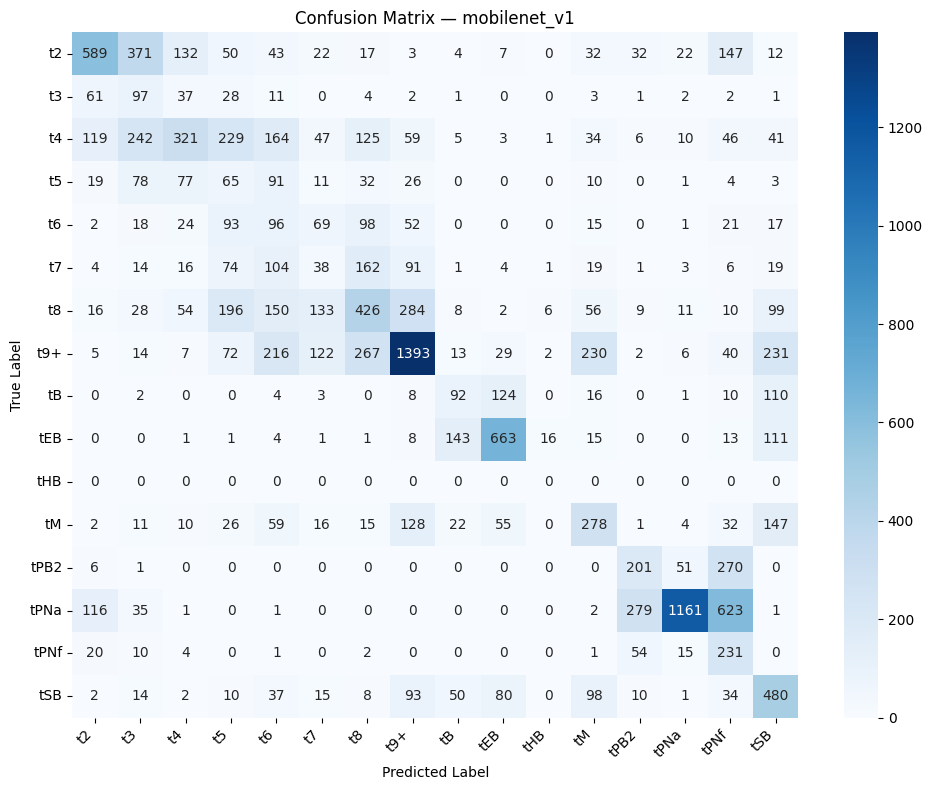


######################################################################
#  MOBILENET_V2
######################################################################
mobilenet_v2 → Trainable: 433,296 / Total: 2,244,368
Loaders ready → img_size=224, batch_size=128
Train: 546 | Val: 112 | Test: 117
Epoch 1/5 | Train Loss: 0.8303 (CE:0.7778, Ord:0.0262) | Acc: 0.3211 || Val Loss: 1.8334, Acc: 0.3531 | 234s
Epoch 2/5 | Train Loss: 0.6165 (CE:0.5880, Ord:0.0143) | Acc: 0.4410 || Val Loss: 1.7204, Acc: 0.4170 | 233s
Epoch 3/5 | Train Loss: 0.5794 (CE:0.5545, Ord:0.0124) | Acc: 0.4684 || Val Loss: 1.6986, Acc: 0.4070 | 236s
Epoch 4/5 | Train Loss: 0.5606 (CE:0.5372, Ord:0.0117) | Acc: 0.4846 || Val Loss: 1.6099, Acc: 0.4512 | 233s
Epoch 5/5 | Train Loss: 0.5432 (CE:0.5217, Ord:0.0107) | Acc: 0.4975 || Val Loss: 1.6288, Acc: 0.4382 | 233s


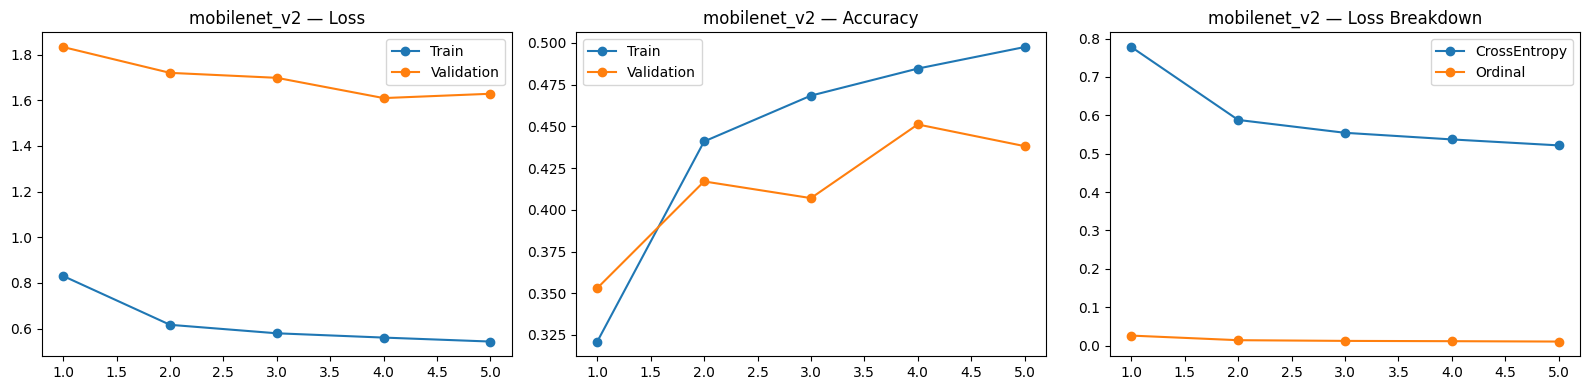


MOBILENET_V2 → Test Accuracy: 42.72%
              precision    recall  f1-score   support

          t2       0.63      0.38      0.47      1483
          t3       0.11      0.34      0.16       250
          t4       0.41      0.31      0.35      1452
          t5       0.07      0.05      0.06       417
          t6       0.11      0.32      0.17       506
          t7       0.06      0.01      0.02       557
          t8       0.37      0.26      0.31      1488
         t9+       0.57      0.61      0.59      2649
          tB       0.27      0.29      0.28       370
         tEB       0.73      0.65      0.68       977
         tHB       0.00      0.00      0.00         0
          tM       0.39      0.31      0.35       806
        tPB2       0.35      0.40      0.37       529
        tPNa       0.86      0.59      0.70      2219
        tPNf       0.15      0.67      0.25       338
         tSB       0.41      0.42      0.42       934

    accuracy                           0.4

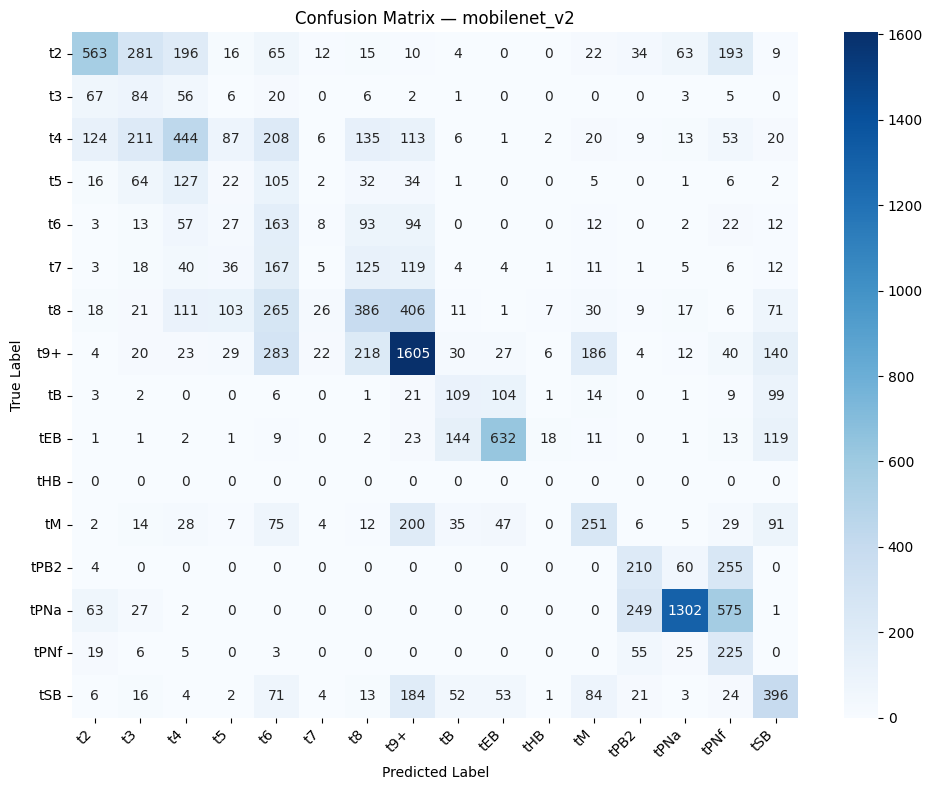


######################################################################
#  INCEPTION_V3
######################################################################
inception_v3 → Trainable: 4,667,152 / Total: 24,388,352
Loaders ready → img_size=299, batch_size=128
Train: 546 | Val: 112 | Test: 117
Epoch 1/5 | Train Loss: 1.6961 (CE:0.6637, Ord:0.0183) | Acc: 0.4028 || Val Loss: 1.4800, Acc: 0.4851 | 401s
Epoch 2/5 | Train Loss: 1.4620 (CE:0.4513, Ord:0.0063) | Acc: 0.5652 || Val Loss: 1.4583, Acc: 0.4929 | 399s
Epoch 3/5 | Train Loss: 1.3900 (CE:0.3880, Ord:0.0051) | Acc: 0.6234 || Val Loss: 1.4351, Acc: 0.5011 | 399s
Epoch 4/5 | Train Loss: 1.3487 (CE:0.3475, Ord:0.0042) | Acc: 0.6688 || Val Loss: 1.4421, Acc: 0.5244 | 400s
Epoch 5/5 | Train Loss: 1.3224 (CE:0.3187, Ord:0.0038) | Acc: 0.6971 || Val Loss: 1.4473, Acc: 0.5098 | 400s


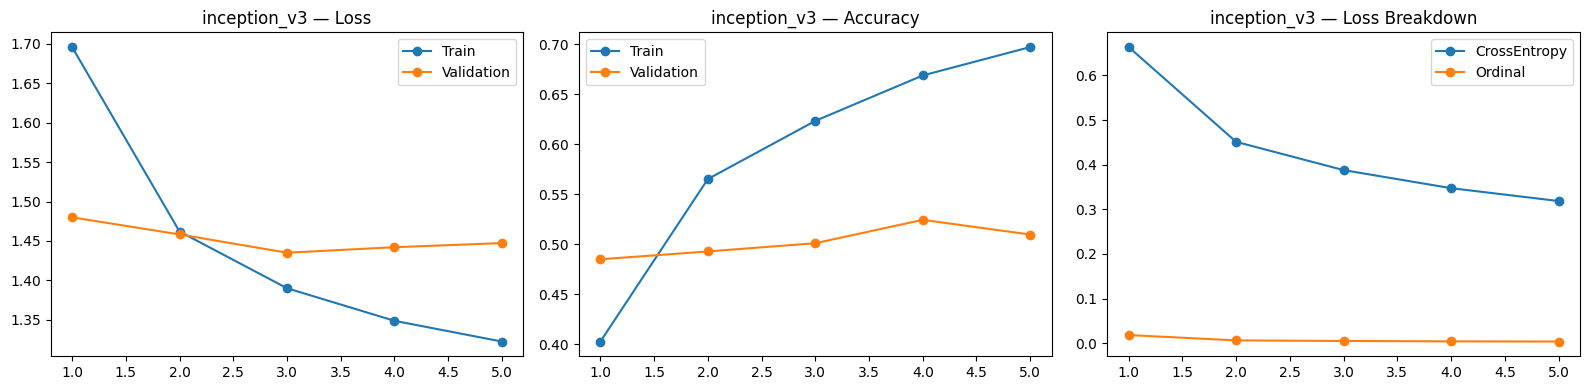


INCEPTION_V3 → Test Accuracy: 47.88%


ValueError: Number of classes, 15, does not match size of target_names, 16. Try specifying the labels parameter

In [45]:
all_results = []

for arch_name in model_list:
    print("\n" + "#" * 70)
    print(f"#  {arch_name.upper()}")
    print("#" * 70)

    # -------------------- BUILD MODEL --------------------
    net, img_dim = create_model(arch_name, NUM_CLASSES, freeze_portion=0.8)

    # -------------------- DATA LOADERS --------------------
    train_loader, val_loader, test_loader = create_data_loaders(
        train_raw,
        val_raw,
        test_raw,
        label_to_id,
        img_size=img_dim,
        batch_size=TRAIN_CFG["batch_size"]
    )

    # -------------------- LOSS --------------------
    loss_fn = HybridLoss(
        class_weights,
        ordinal_map,
        alpha=TRAIN_CFG["ordinal_lambda"]
    )

    # -------------------- OPTIMIZER --------------------
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, net.parameters()),
        lr=TRAIN_CFG["learning_rate"],
        weight_decay=TRAIN_CFG["weight_decay"]
    )

    # -------------------- TRAIN --------------------
    epochs = EPOCH_MAP.get(arch_name, 5)

    net, history = fit_model(
        net,
        train_loader,
        val_loader,
        loss_fn,
        optimizer,
        epochs,
        TRAIN_CFG["early_stop_patience"],
        arch_name
    )

    # -------------------- VISUALIZATION --------------------
    visualize_training(history, arch_name)

    # -------------------- EVALUATION --------------------
    result = evaluate_model_performance(
        net,
        test_loader,
        loss_fn,
        id_to_label,
        arch_name
    )

    all_results.append(result)

    # -------------------- CLEANUP --------------------
    del net, train_loader, val_loader, test_loader
    gc.collect()
    torch.cuda.empty_cache()


print("\nAll models trained successfully ✅")

In [61]:
all_result.append(result)


######################################################################
#  VGG16
######################################################################
vgg16 → Trainable: 16,850,960 / Total: 134,326,096
Loaders ready → img_size=224, batch_size=128
Train: 546 | Val: 112 | Test: 117
Epoch 1/5 | Train Loss: 0.7887 (CE:0.7383, Ord:0.0252) | Acc: 0.3216 || Val Loss: 1.7918, Acc: 0.3904 | 453s
Epoch 2/5 | Train Loss: 0.6516 (CE:0.6172, Ord:0.0172) | Acc: 0.4018 || Val Loss: 1.7321, Acc: 0.4229 | 452s
Epoch 3/5 | Train Loss: 0.6219 (CE:0.5907, Ord:0.0156) | Acc: 0.4263 || Val Loss: 1.6958, Acc: 0.4285 | 453s
Epoch 4/5 | Train Loss: 0.5940 (CE:0.5647, Ord:0.0146) | Acc: 0.4473 || Val Loss: 1.6954, Acc: 0.4232 | 452s
Epoch 5/5 | Train Loss: 0.5885 (CE:0.5609, Ord:0.0138) | Acc: 0.4613 || Val Loss: 1.7101, Acc: 0.4104 | 451s


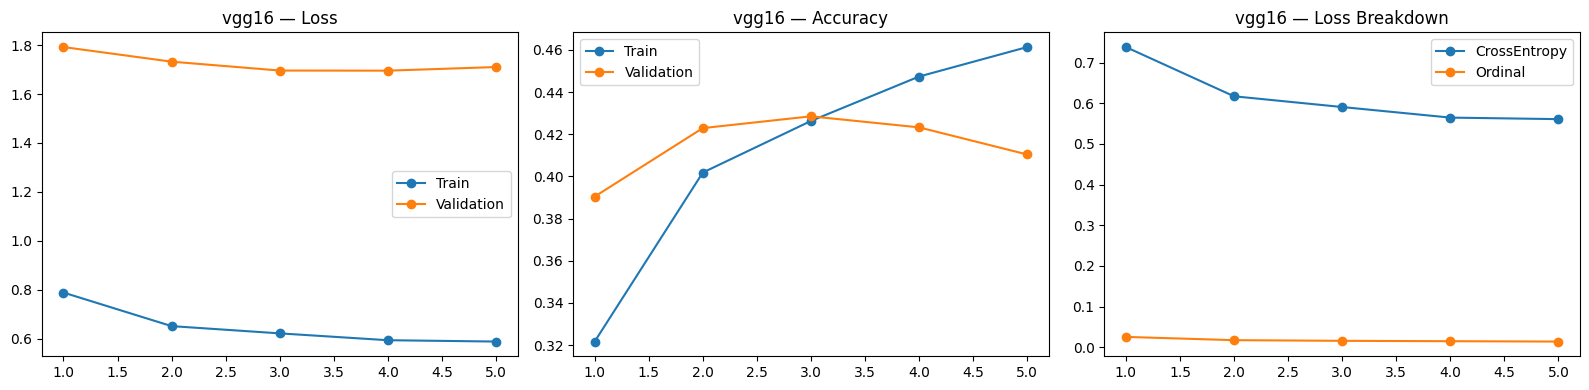


VGG16 → Test Accuracy: 40.55%
              precision    recall  f1-score   support

          t2       0.62      0.40      0.48      1483
          t3       0.09      0.28      0.13       250
          t4       0.50      0.21      0.30      1452
          t5       0.10      0.04      0.06       417
          t6       0.13      0.18      0.15       506
          t7       0.12      0.15      0.13       557
          t8       0.41      0.35      0.38      1488
         t9+       0.58      0.49      0.53      2649
          tB       0.25      0.36      0.30       370
         tEB       0.81      0.55      0.65       977
         tHB       0.00      0.00      0.00         0
          tM       0.22      0.38      0.28       806
        tPB2       0.25      0.83      0.39       529
        tPNa       0.81      0.53      0.64      2219
        tPNf       0.23      0.20      0.21       338
         tSB       0.31      0.47      0.37       934

    accuracy                           0.41     1

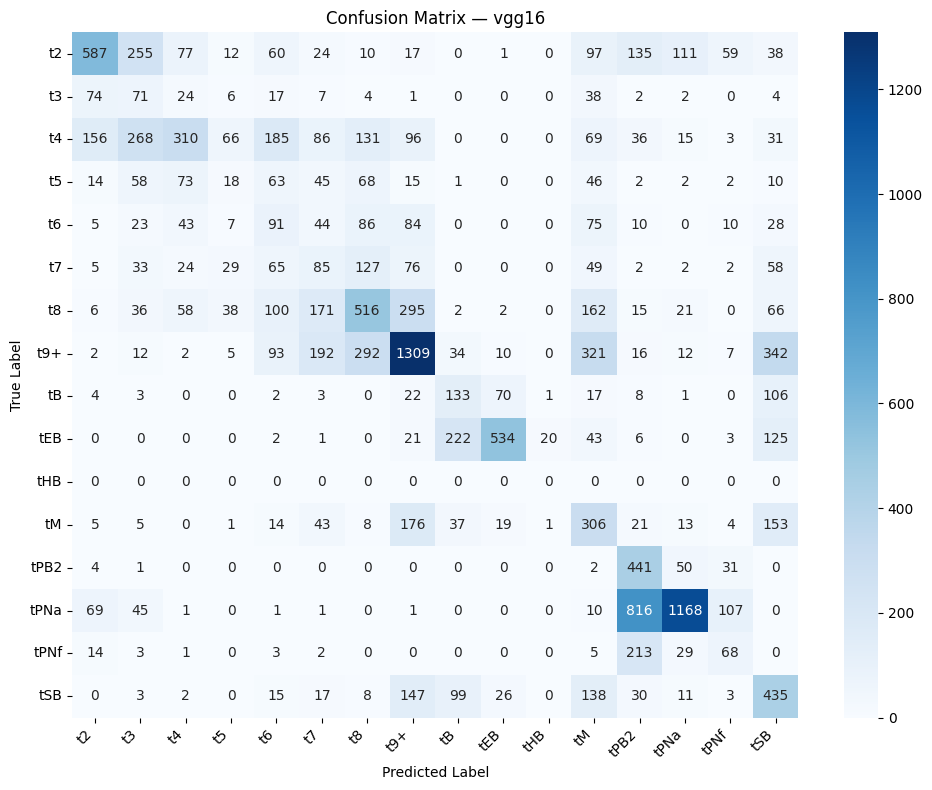

Exception ignored in: <function _ConnectionBase.__del__ at 0x7db86817f560>
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 133, in __del__
    self._close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor



All models trained successfully ✅


In [54]:
# model_list = [
#     "mobilenet_v1",
#     "mobilenet_v2",
#     "inception_v3",
#     "vgg16",
#     "vgg19"
# ]
arch_nm = "vgg16"
print("\n" + "#" * 70)
print(f"#  {arch_nm.upper()}")
print("#" * 70)

    # -------------------- BUILD MODEL --------------------
net, img_dim = create_model(arch_nm, NUM_CLASSES, freeze_portion=0.8)

    # -------------------- DATA LOADERS --------------------
train_loader, val_loader, test_loader = create_data_loaders(
        train_raw,
        val_raw,
        test_raw,
        label_to_id,
        img_size=img_dim,
        batch_size=TRAIN_CFG["batch_size"]
    )

    # -------------------- LOSS --------------------
loss_fn = HybridLoss(
        class_weights,
        ordinal_map,
        alpha=TRAIN_CFG["ordinal_lambda"]
    )

    # -------------------- OPTIMIZER --------------------
optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, net.parameters()),
        lr=TRAIN_CFG["learning_rate"],
        weight_decay=TRAIN_CFG["weight_decay"]
    )

    # -------------------- TRAIN --------------------
epochs = EPOCH_MAP.get(arch_name, 5)

net, history = fit_model(
        net,
        train_loader,
        val_loader,
        loss_fn,
        optimizer,
        epochs,
        TRAIN_CFG["early_stop_patience"],
        arch_name
    )

    # -------------------- VISUALIZATION --------------------
visualize_training(history, arch_nm)

    # -------------------- EVALUATION --------------------
result = evaluate_model_performance(
        net,
        test_loader,
        loss_fn,
        id_to_label,
        arch_nm
    )

all_results.append(result)

    # -------------------- CLEANUP --------------------
del net, train_loader, val_loader, test_loader
gc.collect()
torch.cuda.empty_cache()


print("\nAll models trained successfully ✅")

In [51]:
import torchvision.transforms as T
import torch.optim as optim

In [55]:
NUM_WORKERS = TRAIN_CFG["num_workers"]


######################################################################
#  VGG19
######################################################################
vgg19 → Trainable: 16,850,960 / Total: 139,635,792
Loaders configured → img_size=224, batch_size=128
Train: 546 | Val: 112 | Test: 117
Epoch 1/5 | Train Loss: 0.7824 (CE:0.7299, Ord:0.0262) | Acc: 0.3187 || Val Loss: 1.8598, Acc: 0.3562 | 490s
Epoch 2/5 | Train Loss: 0.6696 (CE:0.6323, Ord:0.0186) | Acc: 0.3967 || Val Loss: 1.8153, Acc: 0.3664 | 492s
Epoch 3/5 | Train Loss: 0.6529 (CE:0.6186, Ord:0.0171) | Acc: 0.4202 || Val Loss: 1.7679, Acc: 0.3773 | 492s
Epoch 4/5 | Train Loss: 0.6306 (CE:0.5979, Ord:0.0163) | Acc: 0.4359 || Val Loss: 1.7270, Acc: 0.4077 | 492s
Epoch 5/5 | Train Loss: 0.5917 (CE:0.5608, Ord:0.0154) | Acc: 0.4492 || Val Loss: 1.7296, Acc: 0.3894 | 492s


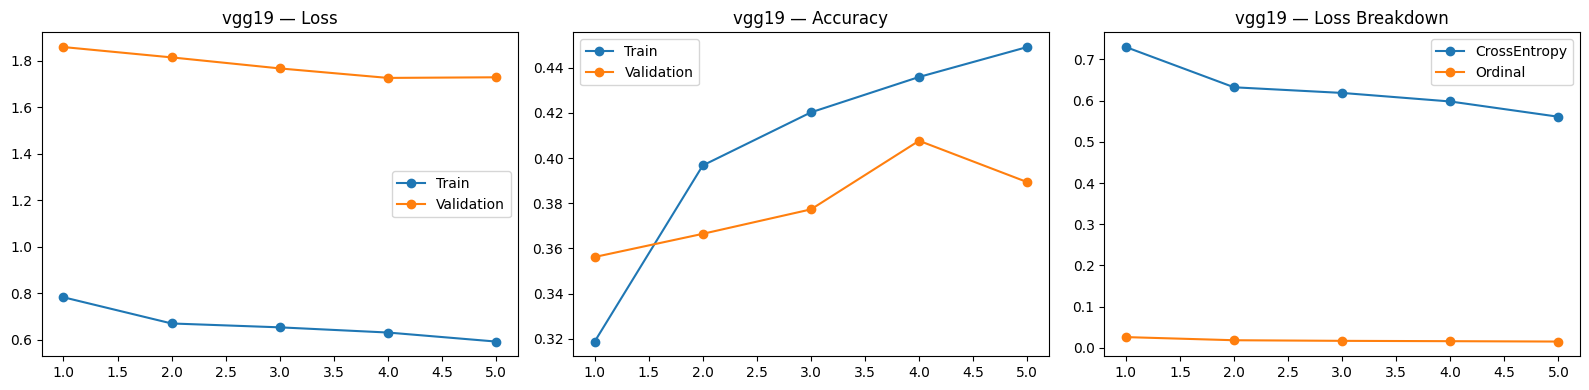


VGG19 → Test Accuracy: 38.94%
              precision    recall  f1-score   support

          t2       0.56      0.55      0.55      1483
          t3       0.11      0.10      0.10       250
          t4       0.39      0.35      0.37      1452
          t5       0.11      0.24      0.15       417
          t6       0.09      0.03      0.05       506
          t7       0.09      0.04      0.06       557
          t8       0.43      0.22      0.29      1488
         t9+       0.59      0.46      0.52      2649
          tB       0.18      0.45      0.26       370
         tEB       0.80      0.44      0.56       977
         tHB       0.00      0.00      0.00         0
          tM       0.22      0.35      0.27       806
        tPB2       0.23      0.79      0.36       529
        tPNa       0.88      0.40      0.55      2219
        tPNf       0.23      0.24      0.23       338
         tSB       0.29      0.57      0.38       934

    accuracy                           0.39     1

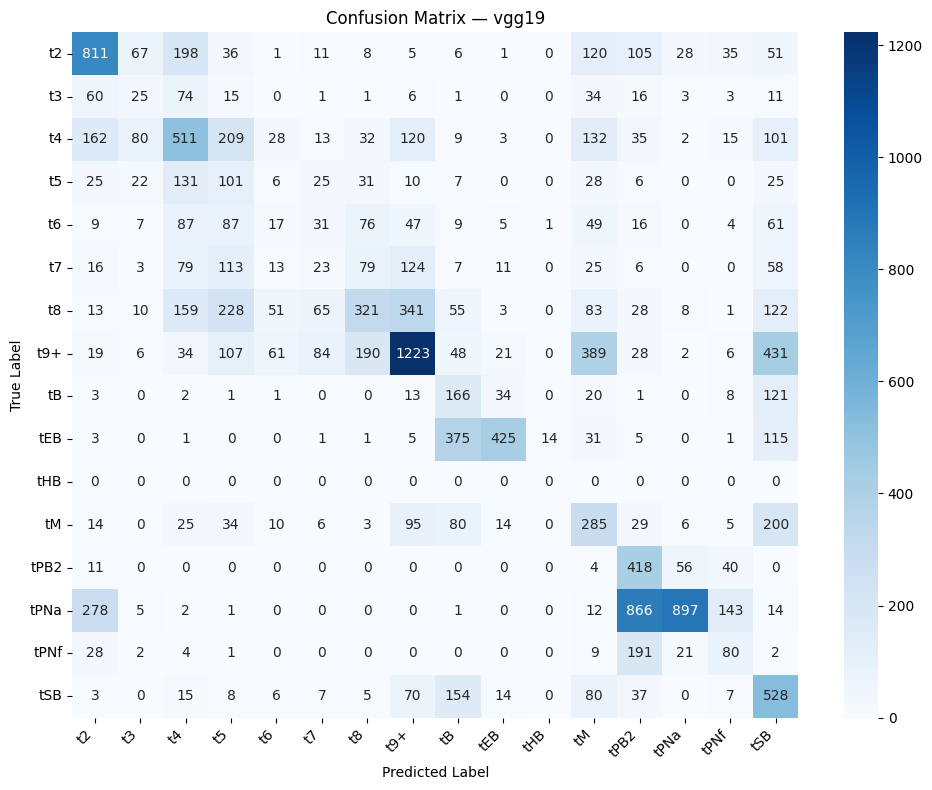

NameError: name 'all_results' is not defined

In [59]:
# model_list = [
#     "mobilenet_v1",
#     "mobilenet_v2",
#     "inception_v3",
#     "vgg16",
#     "vgg19"
# ]
arch_n = "vgg19"
print("\n" + "#" * 70)
print(f"#  {arch_n.upper()}")
print("#" * 70)

    # -------------------- BUILD MODEL --------------------
net, img_dim = create_model(arch_n, NUM_CLASSES, freeze_portion=0.8)

    # -------------------- DATA LOADERS --------------------
train_loader, val_loader, test_loader = create_data_loaders(
        train_raw,
        val_raw,
        test_raw,
        label_to_id,
        img_size=img_dim,
        batch_size=TRAIN_CFG["batch_size"]
    )

    # -------------------- LOSS --------------------
loss_fn = HybridLoss(
        class_weights,
        ordinal_map,
        alpha=TRAIN_CFG["ordinal_lambda"]
    )

    # -------------------- OPTIMIZER --------------------
optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, net.parameters()),
        lr=TRAIN_CFG["learning_rate"],
        weight_decay=TRAIN_CFG["weight_decay"]
    )

    # -------------------- TRAIN --------------------
epochs = EPOCH_MAP.get(arch_n, 5)

net, history = fit_model(
        net,
        train_loader,
        val_loader,
        loss_fn,
        optimizer,
        epochs,
        TRAIN_CFG["early_stop_patience"],
        arch_n
    )

    # -------------------- VISUALIZATION --------------------
visualize_training(history, arch_n)

    # -------------------- EVALUATION --------------------
result = evaluate_model_performance(
        net,
        test_loader,
        loss_fn,
        id_to_label,
        arch_n
    )

all_results.append(result)

    # -------------------- CLEANUP --------------------
del net, train_loader, val_loader, test_loader
gc.collect()
torch.cuda.empty_cache()


print("\nAll models trained successfully ✅")

model  accuracy_pct
vgg19         38.94


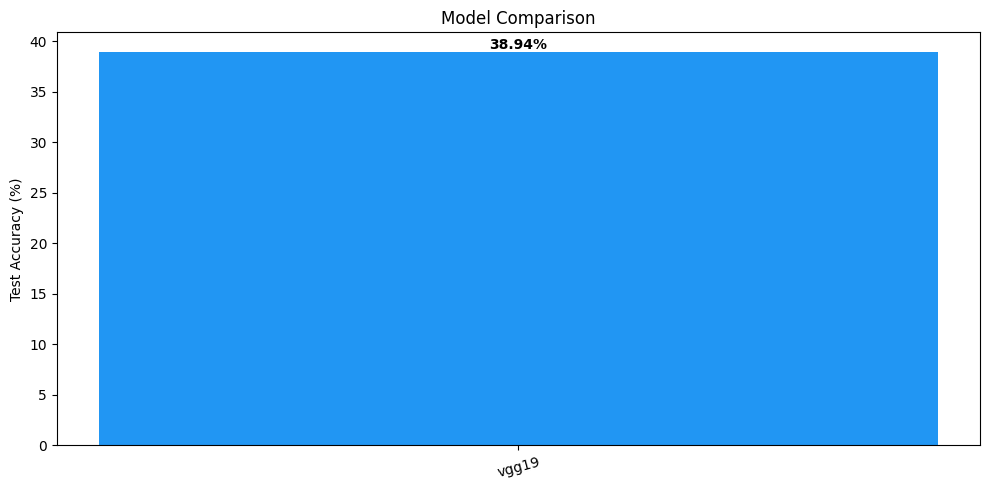


Parameter Comparison:
            Model         Total     Trainable


NameError: name 'build_model' is not defined

In [65]:
if all_result:
    df = pd.DataFrame(all_result)
    df['accuracy_pct'] = (df['accuracy'] * 100).round(2)
    print(df[['model','accuracy_pct']].to_string(index=False))
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']
    ax.bar(df['model'], df['accuracy_pct'], color=colors[:len(df)])
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title('Model Comparison')
    for i, v in enumerate(df['accuracy_pct']):
        ax.text(i, v+0.3, f'{v}%', ha='center', fontweight='bold')
    plt.xticks(rotation=15); plt.tight_layout(); plt.show()
    print("\nParameter Comparison:")
    print(f"  {'Model':>15s}  {'Total':>12s}  {'Trainable':>12s}")
    for mn in df['model']:
        m, _ = build_model(mn, NUM_CLASSES, freeze_ratio=0.8)
        t = sum(p.numel() for p in m.parameters())
        tr = sum(p.numel() for p in m.parameters() if p.requires_grad)
        print(f"  {mn:>15s}  {t:>12,}  {tr:>12,}")
        del m
    torch.cuda.empty_cache()
else:
    print("No results.")